# 03 · ML task T1: high-hike signal (model comparison + validation)
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. Task T1 — can a junior’s skill profile separate high- from low-hike? Candidate model zoo

In [2]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score
JDS = pd.read_excel(f"{DATA_DIR}/JDS_Skill_Traits.xlsx"); JDS.columns = ["id","big_data","maths_stats","coding","ai_ml","story","high_hike"]
SK = ["big_data","maths_stats","coding","ai_ml","story"]
NAMES = {"big_data":"Big data","maths_stats":"Maths & statistics","coding":"Coding","ai_ml":"AI & ML","story":"Dashboards & storytelling"}
X, y = JDS[SK].values, JDS.high_hike.values
groups = JDS.groupby(SK).ngroup().values        # identical skill profiles share a group -> never split across folds
MODELS = {
 "Prevalence baseline":        lambda: DummyClassifier(strategy="prior"),
 "Storytelling-only LR":       lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000)),
 "kNN (k=15)":                 lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
 "Random forest":              lambda: RandomForestClassifier(300, min_samples_leaf=3, random_state=SEED, n_jobs=-1),
 "Gradient boosting":          lambda: GradientBoostingClassifier(n_estimators=120, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEED),
 "RBF-SVM":                    lambda: make_pipeline(StandardScaler(), SVC(C=1.0, probability=True, random_state=SEED)),
 "NEXUS L2 logistic (C=1)":    lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=2000)),
}
def cv_eval(make, Xm, ym, grp, repeats=10, seed=SEED):
    aucs, briers, accs, oofs = [], [], [], []
    for r in range(repeats):
        oof = np.zeros(len(ym))
        for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=seed+r).split(Xm, ym, grp):
            oof[te] = make().fit(Xm[tr], ym[tr]).predict_proba(Xm[te])[:,1]
        aucs.append(roc_auc_score(ym, oof)); briers.append(brier_score_loss(ym, oof)); accs.append(accuracy_score(ym, oof>0.5)); oofs.append(oof)
    return dict(auc=np.mean(aucs), auc_sd=np.std(aucs), brier=np.mean(briers), acc=np.mean(accs)), np.mean(oofs, axis=0)
t0 = time.time(); res, oofs = {}, {}
for name, mk_ in MODELS.items():
    Xm = X[:, [SK.index("story")]] if name.startswith("Storytelling") else X
    res[name], oofs[name] = cv_eval(mk_, Xm, y, groups, repeats=20 if "NEXUS" in name else 10)
tab = pd.DataFrame(res).T.round(3); print(tab.to_string()); print(f"({time.time()-t0:.0f}s)")
save_res("t1_models", {k: {a: float(b) for a, b in v.items()} for k, v in res.items()})

                           auc  auc_sd  brier    acc
Prevalence baseline      0.491   0.000  0.249  0.525
Storytelling-only LR     0.772   0.008  0.169  0.763
kNN (k=15)               0.875   0.006  0.147  0.800
Random forest            0.893   0.006  0.127  0.847
Gradient boosting        0.880   0.009  0.130  0.829
RBF-SVM                  0.886   0.011  0.119  0.853
NEXUS L2 logistic (C=1)  0.902   0.005  0.116  0.863
(29s)


## 2. Validation controls: exact-duplicate removal, permutation test, learning curve

In [3]:
# (a) exact duplicates (same profile AND same label) removed
dd = JDS.drop_duplicates(SK + ["high_hike"]); gd = dd.groupby(SK).ngroup().values
r_dd, _ = cv_eval(MODELS["NEXUS L2 logistic (C=1)"], dd[SK].values, dd.high_hike.values, gd, repeats=10)
print(f"after exact-duplicate removal (n={len(dd)}): AUC={r_dd['auc']:.3f}")
# (b) permutation test: 300 label shuffles through the same grouped CV
rng = np.random.default_rng(SEED); null = []
for i in range(300):
    ys = rng.permutation(y); r_, _ = cv_eval(MODELS["NEXUS L2 logistic (C=1)"], X, ys, groups, repeats=1, seed=1000+i); null.append(r_["auc"])
obs = res["NEXUS L2 logistic (C=1)"]["auc"]
print(f"permutation null AUC: mean={np.mean(null):.3f}, max={np.max(null):.3f}; observed={obs:.3f}; p<{(1+np.sum(np.array(null)>=obs))/(301):.4f}")
# (c) learning curve
lc = {}
for n in [40, 70, 100, 139]:
    a_ = []
    for s in range(15):
        idx = np.random.default_rng(s).choice(len(y), n, replace=False)
        if len(set(y[idx])) < 2: continue
        r_, _ = cv_eval(MODELS["NEXUS L2 logistic (C=1)"], X[idx], y[idx], groups[idx], repeats=1, seed=s); a_.append(r_["auc"])
    lc[n] = float(np.mean(a_))
print("learning curve (AUC by n):", {k: round(v,3) for k, v in lc.items()})
save_res("t1_validation", dict(dedup_auc=float(r_dd["auc"]), dedup_n=len(dd), null_mean=float(np.mean(null)), null_max=float(np.max(null)),
         p=float((1+np.sum(np.array(null)>=obs))/301), learning_curve=lc))

after exact-duplicate removal (n=118): AUC=0.883


permutation null AUC: mean=0.491, max=0.659; observed=0.902; p<0.0033


learning curve (AUC by n): {40: 0.876, 70: 0.896, 100: 0.901, 139: 0.904}


## 3. Calibration, ROC and what the model uses

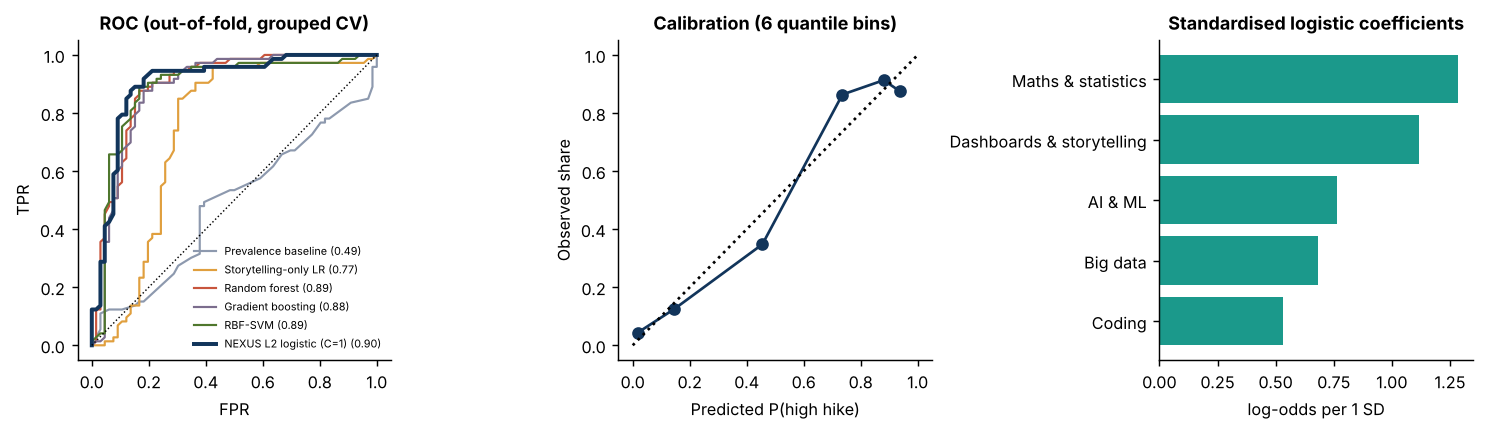

{'Big data': 0.683, 'Maths & statistics': 1.284, 'Coding': 0.533, 'AI & ML': 0.762, 'Dashboards & storytelling': 1.117}
permutation importance (AUC drop): {'Big data': 0.028, 'Maths & statistics': 0.11, 'Coding': 0.015, 'AI & ML': 0.037, 'Dashboards & storytelling': 0.095}


In [4]:
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
best = "NEXUS L2 logistic (C=1)"
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.4))
cols = {"Prevalence baseline":C["grey"], "Storytelling-only LR":C["amber"], "Random forest":C["red"], "Gradient boosting":"#7b6d8d", "RBF-SVM":"#4f772d", best:C["navy"]}
for nme, c in cols.items():
    fpr, tpr, _ = roc_curve(y, oofs[nme]); ax[0].plot(fpr, tpr, color=c, lw=2.2 if nme==best else 1.2, label=f"{nme} ({res[nme]['auc']:.2f})")
ax[0].plot([0,1],[0,1],":",color="k",lw=.8); ax[0].set_title("ROC (out-of-fold, grouped CV)"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(fontsize=6, frameon=False, loc="lower right")
pt, pp = calibration_curve(y, oofs[best], n_bins=6, strategy="quantile"); ax[1].plot(pp, pt, "o-", color=C["navy"]); ax[1].plot([0,1],[0,1],":",color="k")
ax[1].set_title("Calibration (6 quantile bins)"); ax[1].set_xlabel("Predicted P(high hike)"); ax[1].set_ylabel("Observed share")
m = MODELS[best]().fit(X, y); coefs = m[-1].coef_[0]
pi = permutation_importance(m, X, y, scoring="roc_auc", n_repeats=50, random_state=SEED)
order = np.argsort(coefs)
ax[2].barh([NAMES[SK[i]] for i in order], coefs[order], color=[C["teal"] if c>0 else C["red"] for c in coefs[order]]); ax[2].set_title("Standardised logistic coefficients"); ax[2].set_xlabel("log-odds per 1 SD")
plt.tight_layout(); plt.savefig("figs/fig03_t1_model.png", bbox_inches="tight"); plt.show()
print({NAMES[k]: round(float(c),3) for k, c in zip(SK, coefs)})
print("permutation importance (AUC drop):", {NAMES[k]: round(float(v),3) for k, v in zip(SK, pi.importances_mean)})
save_res("t1_coefs", {k: float(c) for k, c in zip(SK, coefs)}); save_res("t1_perm_importance", {k: float(v) for k, v in zip(SK, pi.importances_mean)})
save_res("t1_calibration", dict(pred=pp.tolist(), obs=pt.tolist()))